## **Limpeza e Pré-Processamento de Dados**

##### Tony Esaú de Oliveira - Universidade Federal do Cariri

---

#### **Objetivos**
O objetivo desse *Notebook* é fazer um laboratório de Limpeza e Pré-Processamento de Dados. Dando ênfase as etapas principais e básicas até o resultado final, que é um conjunto de dados mais preciso e mais enriquecedor para uma análise mais profunda e acertada. É importante sempre se lembrar que *Garbage in, garbage out*. 

---

### **1. Estudo do Conjunto de Dados**

##### **1.1 Conjunto de Dados**

O conjunto de dados que usaremos nesse *Notebook* é o **Dirty_Cafe_Sales**, um Conjunto de Dados didático criado para a prática de limpeza de dados. A visão geral fala que: "o conjunto de dados `Dirty_Cafe_Sales` contém 10.000 linhas de dados sintéticos que representam transações de vendas em um café. Este conjunto de dados é intencionalmente 'sujo', com valores ausentes, dados inconsistentes e erros introduzidos para fornecer um cenário realista para limpeza de dados."

##### **1.2 Descrevendo Colunas**


| Coluna | Tipo | Descrição | Exemplo |
|--------|------|-----------|---------|
| **Transaction ID** | Texto | Posição da turnê no ranking atual de maiores arrecadações | 'TXN_1961373' |
| **Item** | Texto | Melhor posição que a turnê já alcançou no ranking histórico | 'Cake' |
| **Quantity** | Inteiro | Melhor posição que a turnê já alcançou no ranking histórico | 1, 2 |
| **Price Per Unit** | Real | Melhor posição que a turnê já alcançou no ranking histórico | 2.0, 2.3 |
| **Total Spent** | Real | Melhor posição que a turnê já alcançou no ranking histórico | 4.0, 15.0 |
| **Payment Method** | Texto | Melhor posição que a turnê já alcançou no ranking histórico | 'Credit Card', 'Cash' |
| **Location** | Texto | Melhor posição que a turnê já alcançou no ranking histórico | 'In-store', 'Takeaway' |
| **Transaction Date** | Data | Melhor posição que a turnê já alcançou no ranking histórico | '2023-06-11' |

### **2. Inspeção e Diagnóstico Inicial**

In [161]:
# Algumas importações básicas.
import pandas as pd
import numpy as np

##### **2.1 Carregamento e Primeira Inspeção**

In [162]:
# Outras possíveis leituras de dados: pd.read_excel(), pd.read_parquet().
dados = pd.read_csv('Dirty_Cafe_Sales.csv') 

Informações básicas:

In [163]:
# Tipos de dados, memória, valores não-nulos.
dados.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


O primeiro problema encontrado: todos as colunas estão do tipo *object*!

In [164]:
# Estatísticas.
dados.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [165]:
# Cabeçalho dos dados: as 10 primeiras linhas.
dados.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


Outro problema aparente: os dados faltantes não estão padronizados! Isso pode vir a ser um problema.

In [166]:
# Cauda dos dados: tamanho de 5.
dados.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [167]:
# 5 amostras aleatórias dos dados.
dados.sample(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4833,TXN_9603773,Cookie,2,1.0,2.0,Credit Card,NaN,2023-10-10
4581,TXN_9073440,Sandwich,2,4.0,8.0,Credit Card,Takeaway,2023-08-28
5719,TXN_4226572,Cookie,3,1.0,3.0,NaN,Takeaway,2023-05-16
2040,TXN_7125392,Cookie,4,UNKNOWN,4.0,Digital Wallet,Takeaway,2023-07-05
3537,TXN_9268974,Sandwich,2,4.0,8.0,Digital Wallet,Takeaway,2023-10-29


In [168]:
# Dimensões do dataset.
print('Dimensões:', dados.shape,'\n')

# Armazenando lista de colunas.
lista_dados = dados.columns.tolist()
print('Lista de colunas:', lista_dados, '\n')

# Tipos de dados de cada coluna.
print('Tipos de dados: \n')
print(dados.dtypes)

# Armazenando tipos de dados em uma lista para ação futura.
tipos_dados = dados.dtypes.to_list() 

Dimensões: (10000, 8) 

Lista de colunas: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date'] 

Tipos de dados: 

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object


Mais adiante podemos também padronizar os nomes das colunas, que normalmente não possuem espaços.

In [169]:
# Vamos observar os valores únicos de cada coluna, exceto a de data de transação e Identificador.
colunas = dados.columns.tolist()
colunas.remove('Transaction ID')
colunas.remove('Transaction Date')

for coluna in colunas:
    print(f'{coluna}:', dados[coluna].unique(), '\n')

Item: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea'] 

Quantity: ['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan] 

Price Per Unit: ['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN'] 

Total Spent: ['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5'] 

Payment Method: ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan] 

Location: ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR'] 



##### **2.2 Análise de Valores Ausentes**

In [170]:
# Colunas com pelo menos um nulo.
dados.isnull().any()

Transaction ID      False
Item                 True
Quantity             True
Price Per Unit       True
Total Spent          True
Payment Method       True
Location             True
Transaction Date     True
dtype: bool

Ou seja, somente a `Transaction ID` não tem valores faltants, isso faz sentido, pois provavelmente essa coluna foi gerada automaticamente como padrão básico do Conjunto de Dados.

In [171]:
# Contagem de nulos por coluna (.isnull() retorna um objeto de mesmo tamanho do DataFrame original 
# e .sum() soma os valores True de cada coluna, em que True significa valor nulo). 
dados.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [172]:
 # Percentual de nulos por coluna.
dados.isnull().sum() / len(dados) * 100

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

Percentualmente, as colunas `Payment Method` e `Location` são as que mais têm valores faltantes. Teremos que tratar mais adiante.

In [173]:
# Percentual de nulos em relação ao total de dados.
tamanho = dados.shape[0] * dados.shape[1]

# Soma o total de todas as colunas.
nulos = dados.isnull().sum().sum() 

print(f'Percentual de valores nulos no dataset: {nulos / tamanho * 100:.2f}%')

Percentual de valores nulos no dataset: 8.53%


É um percentual consideravelemente baixo dado o número de amostras.

<Axes: >

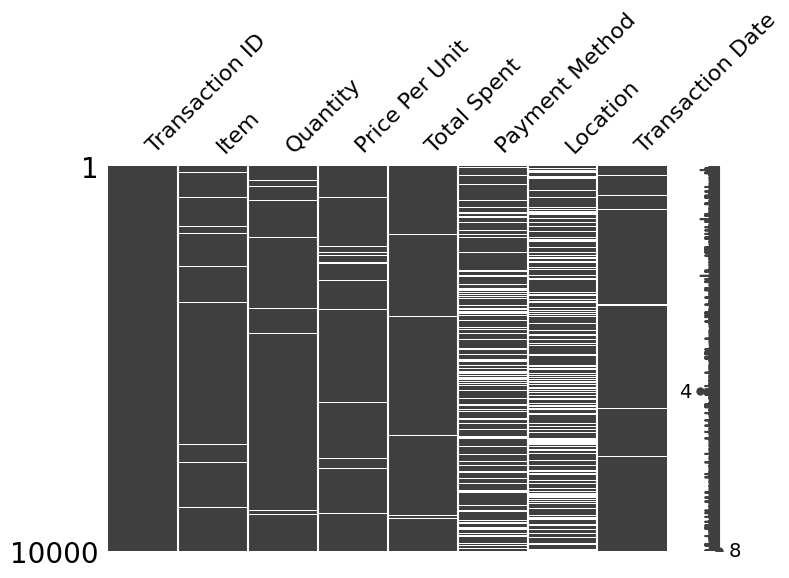

In [174]:
# Biblioteca para visualização de dados faltantes.
import missingno as msno

msno.matrix(dados, figsize=(8, 5))

<Axes: >

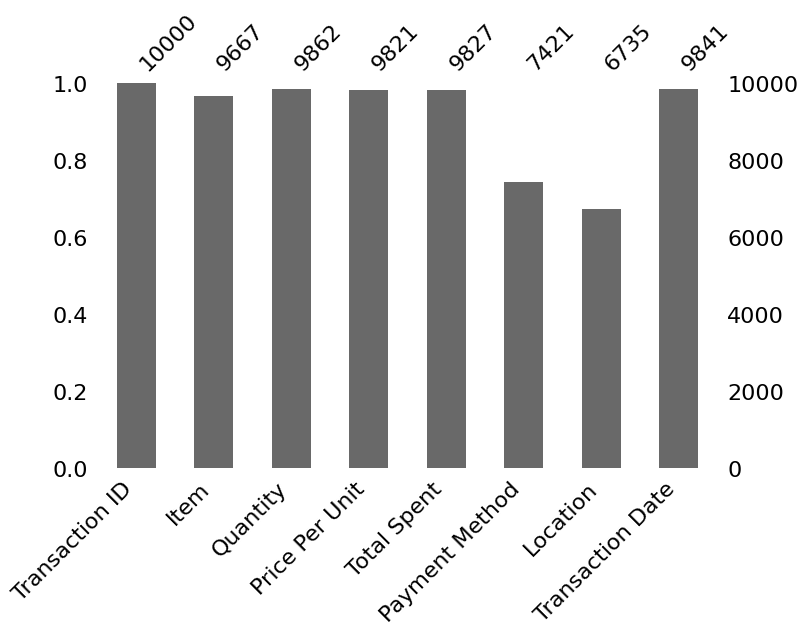

In [175]:
# Plotagem de valores presentes.
msno.bar(dados, figsize=(8, 5))

##### **2.3 Análise e Remoção de Duplicatas**


In [176]:
# Total de linhas duplicadas.
duplicados = dados.duplicated().sum()
print(f'Total de linhas duplicadas é: {duplicados}.')

Total de linhas duplicadas é: 0.


O conjunto de dados não tem duplicatas, o que é uma boa notícia.

##### **2.4 Análise de Tipos de Dados**

In [177]:
dados_objetos = dados.select_dtypes(include=['object'])  # Colunas categóricas/texto
dados_numericos = dados.select_dtypes(include=['number'])  # Colunas numéricas
dados_data = dados.select_dtypes(include=['datetime64'])  # Colunas de data

print('Colunas categóricas/texto:\n', dados_objetos.head(), '\n')
print('Colunas numéricas:\n', dados_numericos.head(), '\n')
print('Colunas de data:\n', dados_data.head(), '\n')

Colunas categóricas/texto:
   Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11   

Colunas numéricas:
 Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4] 

Colunas de data:
 Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4] 



Perceba novamente que precisaremos fazer alterações na tipagem de dados do Conjunto.

### **3. Tratamentos Iniciais**

##### **3.1 Padronizando as Legendas das Colunas e os Tipos**

In [178]:
print('As colunas que se tem são:', lista_dados)

As colunas que se tem são: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


Vamos reescrever essas colunas com um padrão no dataframe original:

In [179]:
legendas = ['transaction_ID', 'item', 'quantity', 'price_per_unity', 'total_spent','payment_method', 'location', 'transaction_date']
dados.columns = legendas
dados.head(10)

,transaction_ID,item,quantity,price_per_unity,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


Vamos olhar novamente os tipos dos dados:

In [180]:
for coluna, tipo in zip(legendas, tipos_dados):
    print(f'Coluna: {coluna} - Tipo de dado: {tipo}')

Coluna: transaction_ID - Tipo de dado: object
Coluna: item - Tipo de dado: object
Coluna: quantity - Tipo de dado: object
Coluna: price_per_unity - Tipo de dado: object
Coluna: total_spent - Tipo de dado: object
Coluna: payment_method - Tipo de dado: object
Coluna: location - Tipo de dado: object
Coluna: transaction_date - Tipo de dado: object


As colunas `quantity`, `price_per_unity`, `total_spent` e `transaction_date` estão com a tipagem errada. Vamos consertar isso.

In [181]:
# O parâmetro errors='coerce' deixa os valores inválidos intocados.
dados['quantity'] = pd.to_numeric(dados['quantity'], errors='coerce').astype('Int64')
dados['price_per_unity'] = pd.to_numeric(dados['price_per_unity'], errors='coerce')
dados['total_spent'] = pd.to_numeric(dados['total_spent'], errors='coerce')
# Convertes a coluna de data para o formato datetime.
dados['transaction_date'] = pd.to_datetime(dados['transaction_date'], errors='coerce')

tipos_dados = dados.dtypes.to_list()


In [182]:
for coluna, tipo in zip(legendas, tipos_dados):
    print(f'Coluna: {coluna} - Tipo de dado: {tipo}')

Coluna: transaction_ID - Tipo de dado: object
Coluna: item - Tipo de dado: object
Coluna: quantity - Tipo de dado: Int64
Coluna: price_per_unity - Tipo de dado: float64
Coluna: total_spent - Tipo de dado: float64
Coluna: payment_method - Tipo de dado: object
Coluna: location - Tipo de dado: object
Coluna: transaction_date - Tipo de dado: datetime64[ns]


Vamos também padronizar os valores ausentes.

In [183]:
# Revendo os valores únicos de cada coluna, exceto a de data de transação e Identificador.
colunas = dados.columns.tolist()
colunas.remove('transaction_ID')
colunas.remove('transaction_date')

for coluna in colunas:
    print(f'{coluna}:', dados[coluna].unique(), '\n')

item: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea'] 

quantity: <IntegerArray>
[2, 4, 5, 3, 1, <NA>]
Length: 6, dtype: Int64 

price_per_unity: [2.  3.  1.  5.  4.  1.5 nan] 

total_spent: [ 4.  12.   nan 10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5] 

payment_method: ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan] 

location: ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR'] 



Os valores 'UNKNOWN', 'nan' e 'ERROR' serão padronizados no tipo padrão de valores ausentes, exceto em `payment_method`, `location` e `transaction date`, pois usaremmos os seus valores iniciais mais pra frente.

In [188]:
# Usaremos a função np.nan() para preencher todos os valores nulos das colunas.
# O termo '<NA>' é um valor ausente do pandas, podendo ser tratado como nulo.
nulos = ['UNKNOWN', 'nan', 'ERROR']

colunas_padrao = colunas
colunas_padrao.remove('payment_method')
colunas_padrao.remove('location')

for coluna in colunas_padrao:
    dados[coluna] = dados[coluna].replace(nulos, np.nan)

Revisando:

In [187]:
colunas = dados.columns.tolist()
colunas.remove('transaction_ID')
colunas.remove('transaction_date')

for coluna in colunas:
    print(f'{coluna}:', dados[coluna].unique(), '\n')

item: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' nan 'Sandwich' 'Juice' 'Tea'] 

quantity: <IntegerArray>
[2, 4, 5, 3, 1, <NA>]
Length: 6, dtype: Int64 

price_per_unity: [2.  3.  1.  5.  4.  1.5 nan] 

total_spent: [ 4.  12.   nan 10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5] 

payment_method: ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan] 

location: ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR'] 



In [189]:
# Vamos ver se o número de valores ausentes aumentou!
dados.isnull().sum()

transaction_ID         0
item                 969
quantity             479
price_per_unity      533
total_spent          502
payment_method      2579
location            3265
transaction_date     460
dtype: int64

##### **3.2 Limpeza de Valores Ausentes e Imputações**

**a) Imputação da Coluna `price_per_unity`**

Alguns valores do Conjunto de Dados podem ser imputados com os dados do próprio conjunto. Por exemplo, a coluna `price_per_unity` pode ser imputada sempre que a coluna `item` não estiver vazia, para isso vamos descobrir o preço de cada item.

In [190]:
# Preços do Conjunto de Dados que são válidos (removendo 'UNKNOWN' e 'ERROR' da coluna 'item').
precos_validos = dados[dados['item'].notna()]

item_preco = (
    precos_validos
    .groupby('item')['price_per_unity']
    .agg(lambda x: x.dropna().mode().iloc[0])
)

print(item_preco) 

item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: price_per_unity, dtype: float64


In [191]:
mascara = dados['price_per_unity'].isna() & dados['item'].isin(item_preco.index)
dados.loc[mascara, 'price_per_unity'] = dados.loc[mascara, 'item'].map(item_preco)

Vamos ver o quanto isso diminuiu os valores ausentes de `price_per_unity`.

In [94]:
dados['price_per_unity'].isnull().sum()

np.int64(54)

Vamos agora usar total gasto e quantidade para tentar diminuir mais ainda esse valor.

In [192]:
# Usar 'total_spent' dividido por 'quantity' para preencher os valores nulos em 'price_per_unity'.

mask = dados['price_per_unity'].isna() & dados['quantity'].notna() & dados['total_spent'].notna()

dados.loc[mask, 'price_per_unity'] = (
    dados.loc[mask, 'total_spent'] / dados.loc[mask, 'quantity']
)

In [193]:
dados['price_per_unity'].isnull().sum()

np.int64(6)

Reduziu bastante o número de valores faltantes na coluna `price_per_unity`. Para fazer uma análise mais profunda vejamos quais são essas amostras específicas.

In [194]:
dados[dados['price_per_unity'].isnull() == True]

,transaction_ID,item,quantity,price_per_unity,total_spent,payment_method,location,transaction_date
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4,NaN,NaN,ERROR,NaN,2023-12-09
3779,TXN_7376255,NaN,<NA>,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,NaN,2,NaN,NaN,NaN,In-store,2023-12-14
7597,TXN_1082717,NaN,<NA>,NaN,9.0,Digital Wallet,In-store,2023-12-13
9819,TXN_1208561,NaN,<NA>,NaN,20.0,Credit Card,NaN,2023-08-19


Perceba como essas linhas são problemáticas! Não se tem o item em nenhuma e ainda é impossível fazer algumas imputações em funções de outras colunas. Por isso, mais pra frente, provavelmente, teremos que deletar esse tipo de linhas, mas antes vamos fazer mais imputações.

**b) Imputação da Coluna `Item`**

In [195]:
# Tem 969 valores ausentes.
dados.isnull().sum()

transaction_ID         0
item                 969
quantity             479
price_per_unity        6
total_spent          502
payment_method      2579
location            3265
transaction_date     460
dtype: int64

In [196]:
# Vamos imputar 'item' a partir de precos_validos, o problema é que alguns itens tem preços iguais. Vamos ignorá-los, por enquanto.

preco_item_unico = (
    item_preco.reset_index()
    .groupby('price_per_unity')
    .filter(lambda x: len(x) == 1) # Tamanho = 1, ou seja, tem um único item associado a esse preço.
    .set_index('price_per_unity')['item']
)

# Imputando.
dados['item'] = dados.apply(
    lambda row: preco_item_unico[row['price_per_unity']]
    if pd.isna(row['item']) and row['price_per_unity'] in preco_item_unico.index
    else row['item'],
    axis=1
)

In [197]:
preco_item_unico

price_per_unity
2.0    Coffee
1.0    Cookie
5.0     Salad
1.5       Tea
Name: item, dtype: object

In [198]:
# O número caiu próximo da metade.
dados['item'].isnull().sum()

np.int64(480)

O que significa que 480 itens estão ente Cake (3.0), Juice (3.0), Sandwich (4.0) e Smoothie (4.0). Para imputar o restante vamos usar uma distribuição justa que não interfira gravemente nas informações do dados!

In [199]:
# Vamos guardar essa distribuição para usá-la na imputação.
dist_item_preco = (
    dados
    .dropna(subset=['item', 'price_per_unity']) # Os ausentes não nos interessa.
    .groupby('price_per_unity')['item']
    .value_counts(normalize=True) # Normalizamos.
)

dist_item_preco


price_per_unity  item    
1.0              Cookie      1.000000
1.5              Tea         1.000000
2.0              Coffee      1.000000
3.0              Juice       0.506926
                 Cake        0.493074
4.0              Sandwich    0.507858
                 Smoothie    0.492142
5.0              Salad       1.000000
Name: proportion, dtype: float64

In [200]:
# Vamos tirar os preços que são únicos. 
dist_item_preco = dist_item_preco[dist_item_preco < 1.0]
dist_item_preco

price_per_unity  item    
3.0              Juice       0.506926
                 Cake        0.493074
4.0              Sandwich    0.507858
                 Smoothie    0.492142
Name: proportion, dtype: float64

Incrivelmente, a distribuição é bem igualitária, em torno de 50% para os dois itens. Vamos imputar probalisticamente (heurística):

In [201]:
# Função para imputar os dados.

def imputar_item(row):
    if pd.isna(row['item']) and row['price_per_unity'] in dist_item_preco.index: # Se o item for ausente na linha e o preço estiver nos índices conhecidos.
        opcoes = dist_item_preco.loc[row['price_per_unity']] # O loc pega o preço correspondente na linha, gera um dado do tipo 'index = item: value = proporções'.
        return np.random.choice(opcoes.index, p = opcoes.values) # Gera o valor de item com base na distribuição.
    return row['item']

dados['item'] = dados.apply(imputar_item, axis=1)

Perceba abaixo que a disribuição continua boa e bem próxima da anterior.

In [202]:
dist_item_preco = (
    dados
    .dropna(subset=['item', 'price_per_unity'])
    .groupby('price_per_unity')['item']
    .value_counts(normalize=True) # Normalizamos.
)

dist_item_preco

price_per_unity  item    
1.0              Cookie      1.000000
1.5              Tea         1.000000
2.0              Coffee      1.000000
3.0              Juice       0.508799
                 Cake        0.491201
4.0              Sandwich    0.506112
                 Smoothie    0.493888
5.0              Salad       1.000000
Name: proportion, dtype: float64

E chegamos no mesmo valores de ausentes da coluna `price_per_item`.

In [203]:
dados['item'].isnull().sum()

np.int64(6)

**c) Imputação da Coluna `Item`**

In [204]:
# Revisando.
dados.isnull().sum()

transaction_ID         0
item                   6
quantity             479
price_per_unity        6
total_spent          502
payment_method      2579
location            3265
transaction_date     460
dtype: int64

A partir de `price_per_unity` e `quantity` provavelmente podemos calcular alguns valores da coluna `total_spent`.

In [205]:
# Calcula só onde total_spent é nulo, convertendo pra float.
dados.loc[dados['total_spent'].isna(), 'total_spent'] = (
    (dados['price_per_unity'] * dados['quantity']).astype(float)
)

Vamos ver quantas fileiras poderam ser imputadas.

In [206]:
dados['total_spent'].isnull().sum()

np.int64(23)

Sobraram somente 23 fileiras em relação a `total_spent` com valores nulos! Um número bom. Dito isso, não podemos fazer mais muitas coisas devido a falta de informações, devemos partir para a coluna `quantity` e depois tentar fazer mais algumas imputações finais.  

**d) Imputação da Coluna `Quantity`**

Vamos ver quantos nulos existem atualmente na coluna `qunatity`.

In [207]:
dados['quantity'].isnull().sum()

np.int64(479)

Agora, faremos uma imputação básica similar a feita anteriormente com `total_spent`:

In [208]:
# Dividimos o total pelo preço por unidade.
dados.loc[dados['quantity'].isna(), 'quantity'] = (
    (dados['total_spent'] / dados['price_per_unity'])
    .round()
    .astype('Int64')
)


In [209]:
dados.isnull().sum()

transaction_ID         0
item                   6
quantity              23
price_per_unity        6
total_spent           23
payment_method      2579
location            3265
transaction_date     460
dtype: int64

Verificamos se essas 6 fileiras estão dentro dessas outras 23. 

In [210]:
# Índices onde price_per_unity é nulo.
indice_price_na = dados[dados['price_per_unity'].isna()].index

# Índices onde total_spent é nulo
ind_total_na = dados[dados['total_spent'].isna()].index

# Verificar se todos os price_na estão dentro dos total_na.
indice_price_na.isin(ind_total_na).all()


np.False_

A resposta foi falso, então devemos observar os dados faltantes separadamente.

In [211]:
dados[dados['price_per_unity'].isnull()]

,transaction_ID,item,quantity,price_per_unity,total_spent,payment_method,location,transaction_date
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4,NaN,NaN,ERROR,NaN,2023-12-09
3779,TXN_7376255,NaN,<NA>,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,NaN,2,NaN,NaN,NaN,In-store,2023-12-14
7597,TXN_1082717,NaN,<NA>,NaN,9.0,Digital Wallet,In-store,2023-12-13
9819,TXN_1208561,NaN,<NA>,NaN,20.0,Credit Card,NaN,2023-08-19


In [212]:
dados[dados['total_spent'].isnull()]

,transaction_ID,item,quantity,price_per_unity,total_spent,payment_method,location,transaction_date
236,TXN_8562645,Salad,<NA>,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,<NA>,3.0,NaN,Cash,Takeaway,2023-04-15
641,TXN_2962976,Juice,<NA>,3.0,NaN,NaN,NaN,2023-03-17
738,TXN_8696094,Sandwich,<NA>,4.0,NaN,NaN,Takeaway,2023-05-14
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4,NaN,NaN,ERROR,NaN,2023-12-09
2796,TXN_9188692,Cake,<NA>,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,<NA>,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3224,TXN_6297232,Coffee,<NA>,2.0,NaN,NaN,NaN,2023-04-07
3401,TXN_3251829,Tea,<NA>,1.5,NaN,Digital Wallet,In-store,2023-07-25


Veja que em relação as colunas numéricas não há muitos mais o que se possa fazer, é impossível qualquer imputação. Partiremos agora para as imputações categóricas.

**e) Imputação das colunas `payment_method` e `location`.**

In [213]:
# Revisando os valores únicos.

print(dados['payment_method'].unique())
print(dados['location'].unique())


['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']


Não há muito o que se possar fazer com imputação em relação às colunas categóricas, o mais interessante é que usássemos modas ou outros parâmetros para imputar valores. Porém, o método mais seguro é colocar valores padrões ou deixar alguns que estão, seja para indicar inconsistência ou fazer outros estudos. No nosso caso, tanto na coluna `payment_method`, quanto em `location` trataremos valores ausentes e 'UNKNOWN' como 'unknown', isto é, desconhecido e 'ERROR' com um erro interno chamado 'error'. 

In [214]:
# Método desconhecido.
dados.loc[
    (dados['payment_method'] == 'UNKNOWN') | (dados['payment_method'].isna()),
    'payment_method'
] = 'Unknown'

# Método que deu erro.
dados.loc[dados['payment_method'] == 'ERROR', 'payment_method'] = 'Error'

In [215]:
# Localização desconhecida.
dados.loc[
    (dados['location'] == 'UNKNOWN') | (dados['location'].isna()),
    'location'
] = 'Unknown'

# Algum erro na localização.
dados.loc[dados['location'] == 'ERROR', 'location'] = 'Error'

Agora, revisando os valores únicos:

In [216]:
print(dados['payment_method'].unique())
print(dados['location'].unique())

['Credit Card' 'Cash' 'Unknown' 'Digital Wallet' 'Error']
['Takeaway' 'In-store' 'Unknown' 'Error']


In [217]:
# Valores faltantes.
dados.isnull().sum()

transaction_ID        0
item                  6
quantity             23
price_per_unity       6
total_spent          23
payment_method        0
location              0
transaction_date    460
dtype: int64

**f) Imputação das colunas `transaction_date`.**

Não podemos fazer imputações ao acaso nem garantir propriedades com as datas de transações, logo, colocaremos todos os ausentes como nulos.

In [229]:
dados['transaction_date'] = pd.to_datetime(dados['transaction_date'], errors='coerce')

##### **Eliminando valores ausentes por Limiar**

Como já vimos, linhas que possuem apenas um elemento não nulo entre as três colunas numéricas não nos interessa, pois não podemos lhe inputar nenhum valor. Logo, faremos uma dropagem de linha por limiar nesse subconjunto de colunas.

In [230]:
dados = dados.dropna(
    subset=['quantity', 'price_per_unity', 'total_spent'],
    thresh=2
)

In [ ]:
# Observamos que exatamente as 26 linhas problemáticas foram eliminadas (três não estavam entre as 23 de 'spent'):
dados.shape

(9974, 8)

Agora existem somente datas de transação nulas. Dependendo da análise essas linhas podem ser dropadas ou até a coluna toda, mas nesse caso manteremos.

In [ ]:
dados.isnull().sum()

transaction_ID        0
item                  0
quantity              0
price_per_unity       0
total_spent           0
payment_method        0
location              0
transaction_date    460
dtype: int64

### **4. Detectando Anomalias (Outliers)**

Dados numéricos anomálicos podem ser tratados por meio de métodos estatísticos como o estudo dos quartis e do Z-score.

In [234]:
# Vamos usar o IQR e o Z-Score para detectar outliers em uma coluna numérica específica.

colunas_numericas = dados.select_dtypes(include=['number']).columns.tolist()
colunas_numericas

['quantity', 'price_per_unity', 'total_spent']

In [ ]:
anomalias_IQR = {}
anomalias_ZScore = {}
anomalias_inter = {} # Vamos tratar anomalias somente na interseção dos dois métodos.

for coluna in colunas_numericas:

    # Detectando com IQR.
    Q1 = dados[coluna].quantile(0.25)
    Q3 = dados[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf_iqr = Q1 - 1.5 * IQR
    limite_sup_iqr = Q3 + 1.5 * IQR

    mascara_iqr = (dados[coluna] < limite_inf_iqr) | (dados[coluna] > limite_sup_iqr)
    anomalias_IQR[coluna] = dados[mascara_iqr]

    # Z-Score.
    media = dados[coluna].mean()
    desvio = dados[coluna].std()
    limite_inf_z = media - 3 * desvio
    limite_sup_z = media + 3 * desvio

    mascara_z = (dados[coluna] < limite_inf_z) | (dados[coluna] > limite_sup_z)
    anomalias_ZScore[coluna] = dados[mascara_z]

    # Interseção.
    mascara_comum = mascara_iqr & mascara_z
    anomalias_inter[coluna] = dados[mascara_comum]
    

In [236]:
for coluna, df_outliers in anomalias_inter.items():
    print("=" * 80)
    print(f"Anomalias confirmadas por IQR ∩ Z-Score — Coluna: {coluna}")
    print("=" * 80)
    print(f"Total de anomalias: {len(df_outliers)}\n")

    if len(df_outliers) == 0:
        print("Nenhuma anomalia confirmada.\n")
    else:
        display(df_outliers)

    print("\n\n")

Anomalias confirmadas por IQR ∩ Z-Score — Coluna: quantity
Total de anomalias: 0

Nenhuma anomalia confirmada.




Anomalias confirmadas por IQR ∩ Z-Score — Coluna: price_per_unity
Total de anomalias: 0

Nenhuma anomalia confirmada.




Anomalias confirmadas por IQR ∩ Z-Score — Coluna: total_spent
Total de anomalias: 0

Nenhuma anomalia confirmada.






A ausência de interseção entre IQR e Z-score indica que não há outliers robustos, embora possam ocorrer detecções pontuais em cada método individualmente.

### **5. Modificações Finais**

Ah, é possível também adiocionar novas colunas a partir de outras, mas, nesse laboratório em específico, não faremos isso. Em parte porque os dados já estão bem detalhados e também porque isso pode depender de uma interpretação particular e objetivos específicos da análise (Para quê queremos os dados?) e esse notebook tem a intenção de ser generalista!

In [ ]:
# Ordenar por datas.
dados = dados.sort_values('transaction_date')
dados.head(10)

In [242]:
# Podemos resetar os índices.
dados = dados.sort_values('transaction_date').reset_index(drop=True)
dados

,transaction_ID,item,quantity,price_per_unity,total_spent,payment_method,location,transaction_date
0,TXN_5358805,Coffee,5,2.0,10.0,Digital Wallet,Error,2023-01-01
1,TXN_2104473,Cake,3,3.0,9.0,Digital Wallet,Takeaway,2023-01-01
2,TXN_1604072,Coffee,2,2.0,4.0,Unknown,Unknown,2023-01-01
3,TXN_8249251,Cake,3,3.0,9.0,Error,In-store,2023-01-01
4,TXN_2024598,Sandwich,1,4.0,4.0,Digital Wallet,In-store,2023-01-01
...,...,...,...,...,...,...,...,...
9969,TXN_9460419,Cake,1,3.0,3.0,Unknown,Takeaway,NaT
9970,TXN_8253472,Cake,1,3.0,3.0,Unknown,Unknown,NaT
9971,TXN_3130865,Juice,3,3.0,9.0,Unknown,In-store,NaT
9972,TXN_9226047,Smoothie,3,4.0,12.0,Cash,Unknown,NaT


---

A limpeza está finalizada! Agora o data set está pronto para ser utilizado para objetivos específicos.

In [246]:
dados.describe()

,quantity,price_per_unity,total_spent,transaction_date
count,9974.0,9974.000000,9974.000000,9514
mean,3.024865,2.946962,8.927411,2023-07-01 23:14:35.593861632
min,1.0,1.000000,1.000000,2023-01-01 00:00:00
25%,2.0,2.000000,4.000000,2023-04-01 00:00:00
50%,3.0,3.000000,8.000000,2023-07-02 00:00:00
75%,4.0,4.000000,12.000000,2023-10-02 00:00:00
max,5.0,5.000000,25.000000,2023-12-31 00:00:00
std,1.420504,1.280144,6.002644,NaN


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9974 entries, 0 to 9973
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_ID    9974 non-null   object        
 1   item              9974 non-null   object        
 2   quantity          9974 non-null   Int64         
 3   price_per_unity   9974 non-null   float64       
 4   total_spent       9974 non-null   float64       
 5   payment_method    9974 non-null   object        
 6   location          9974 non-null   object        
 7   transaction_date  9514 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(4)
memory usage: 633.2+ KB


Podemos salvá-lo:

In [247]:
dados.to_csv('Cleaned_Cafe_Sales.csv', index=False)